# Breast cancer prognosis

#### Import libraries

In [55]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, DotProduct
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import KernelPCA

from collections import Counter
from scipy.optimize import linear_sum_assignment


## Data import and preprocessing

In [56]:
# Data import 
repoinfo = fetch_ucirepo(id=16)
X = repoinfo.data.features.values.astype(float)
y = repoinfo.data.targets.values.ravel()

# handle missing values in X(replace with column mean)
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# scale transform the values in X
scaler = StandardScaler()
Xt = scaler.fit_transform(X)

# encode y labels to numbers if they are strings
le = LabelEncoder()
yt = le.fit_transform(y)

# confirm everything looks right
print(Xt.shape)
print(yt.shape)
print(np.unique(y, return_counts=True))
print(y[-10:], yt[-10:])
print(np.mean(X, axis=0))  ## original data mean
print("Normalized values are zero except for roundoff errors:")
print(np.mean(Xt, axis=0)) ## normalized data mean
print(np.std(X, axis=0))  ## original data scale 
print(np.std(Xt, axis=0)) ## normalized data scale

(198, 33)
(198,)
(array(['N', 'R'], dtype=object), array([151,  47]))
['N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'R' 'N'] [0 0 0 0 0 0 0 0 1 0]
[4.67323232e+01 1.74123232e+01 2.22760101e+01 1.14856566e+02
 9.70040909e+02 1.02681414e-01 1.42647778e-01 1.56242778e-01
 8.67756061e-02 1.92754040e-01 6.27055051e-02 6.03346465e-01
 1.26445000e+00 4.25539394e+00 7.02287374e+01 6.76186364e-03
 3.11992929e-02 4.07497980e-02 1.50992525e-02 2.05548586e-02
 3.98690404e-03 2.10218182e+01 3.01390909e+01 1.40347778e+02
 1.40495859e+03 1.43920758e-01 3.65101818e-01 4.36685303e-01
 1.78777525e-01 3.23404040e-01 9.08281313e-02 2.84747475e+00
 3.21134021e+00]
Normalized values are zero except for roundoff errors:
[-3.58859968e-17 -9.15092917e-16  7.89491929e-16  3.05030972e-16
  4.48574959e-16 -1.34572488e-16  3.36431220e-16  2.78116475e-16
  6.36976442e-16 -8.79206921e-16 -4.30631961e-16  1.97372982e-16
 -5.83147447e-16  3.58859968e-17  0.00000000e+00 -2.28773229e-16
  1.52515486e-16  1.77187109e-16 -4.66517958e-

## Classification

### K-nearest neighbor and Gaussian process classifier hyperparametrization

In [68]:
# Number of runs

N_RUNS      = 10
OUTER_FOLDS = 5
INNER_FOLDS = 5

# Parameter grids
# knn - k and metric
knn_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "metric":      ["euclidean", "manhattan"],
}
# gpc - kernel functions
gpc_grid = {
    "kernel": [RBF(),Matern(),RationalQuadratic(),DotProduct()],
}

# Storage
knn_accs, gpc_accs   = [], []
knn_preds, knn_ks, knn_mets   = [], [], []
gpc_preds, gpc_kf              = [], []
true_labels = []

rng = np.random.default_rng()

for run in range(N_RUNS):

    # Random permutation
    perm   = rng.permutation(len(y))
    X_p, y_p = Xt[perm], yt[perm]

    fold_true = []

    outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS)
    inner_cv = StratifiedKFold(n_splits=INNER_FOLDS)

    # KNN cross validation 
    knn_base  = KNeighborsClassifier()
    knn_inner = GridSearchCV(knn_base, knn_grid, cv=inner_cv,
                             scoring="balanced_accuracy", n_jobs = -1)

    fold_knn_preds, fold_accs, fold_ks, fold_ms = [], [], [], []
    for train_idx, test_idx in outer_cv.split(X_p, y_p):
        knn_inner.fit(X_p[train_idx], y_p[train_idx])
        fold_knn_preds.append(knn_inner.predict(X_p[test_idx]))  # predict labels
        fold_accs.append(np.mean(fold_knn_preds[-1] == y_p[test_idx])) # calculate accuracy
        fold_ks.append(knn_inner.best_params_["n_neighbors"])
        fold_ms.append(knn_inner.best_params_["metric"])


    knn_accs.append(np.mean(fold_accs))
    knn_preds.append(np.concatenate(fold_knn_preds))
    knn_ks.append(np.mean(fold_ks))         
    # most-frequent metric across folds
    knn_mets.append(max(set(fold_ms), key=fold_ms.count))
    

    # GPC cross validation 
    gpc_base = GaussianProcessClassifier(n_restarts_optimizer=10)
    gpc_inner = GridSearchCV(gpc_base, gpc_grid, cv=inner_cv,
                             scoring="balanced_accuracy", n_jobs = -1)

    fold_gpc_preds, fold_accs_g, fold_kf = [], [], []
    for train_idx, test_idx in outer_cv.split(X_p, y_p):
        gpc_inner.fit(X_p[train_idx], y_p[train_idx])
        fold_gpc_preds.append(gpc_inner.predict(X_p[test_idx]))
        fold_accs_g.append(np.mean(fold_gpc_preds[-1] == y_p[test_idx]))
        fold_kf.append((type(gpc_inner.best_params_["kernel"]).__name__))

        fold_true.append(y_p[test_idx]) #get true labels

    gpc_accs.append(np.mean(fold_accs_g))
    gpc_preds.append(np.concatenate(fold_gpc_preds))
    gpc_kf.append(max(set(fold_kf), key=fold_kf.count))
    true_labels.append(np.concatenate(fold_true)) # concat all true labels
    

    
# best hyperparameters 
knn_accs = np.array(knn_accs)
print(f"Accuracy of the KNN:{knn_accs}")
gpc_accs = np.array(gpc_accs)
print(f"Accuracy of the GPC:{gpc_accs}")
knn_ks   = np.array(knn_ks)
print(f"The best K for KNN:{knn_ks}")
gpc_kf   = gpc_kf # for the sake of having results listed together
print(f"The best kernel function for GPC:{gpc_kf}")
knn_mets = knn_mets # for the sake of having results listed together
print(f"The best KNN metric:{knn_mets}")

Accuracy of the KNN:[0.6825641  0.69666667 0.73794872 0.70730769 0.72705128 0.68179487
 0.74717949 0.70205128 0.70730769 0.70230769]
Accuracy of the GPC:[0.78833333 0.79269231 0.79807692 0.81320513 0.8074359  0.79346154
 0.80282051 0.80320513 0.80320513 0.81833333]
The best K for KNN:[2.6 1.8 5.  1.4 2.6 1.8 3.8 1.8 4.2 1.4]
The best kernel function for GPC:['DotProduct', 'DotProduct', 'DotProduct', 'DotProduct', 'DotProduct', 'DotProduct', 'DotProduct', 'DotProduct', 'DotProduct', 'DotProduct']
The best KNN metric:['euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean', 'euclidean']


#### Significance testing KNN vs GPC

In [ ]:

# Wilcoxon (not optimal)
stat, p = wilcoxon(knn_accs, gpc_accs)
print(f"\nWilcoxon signed-rank test: stat={stat:.3f}, p={p:.4f}")
sig = "significantly" if p < 0.05 else "not significantly"
print(f"KNN and GPC are {sig} different at α=0.05")

print(f"Mean KNN accuracy {knn_accs.mean():.3f}")
print(f"Mean GPC accuracy {gpc_accs.mean():.3f}")




Wilcoxon signed-rank test: stat=0.000, p=0.0020
KNN and GPC are significantly different at α=0.05
Mean KNN accuracy 0.712
Mean GPC accuracy 0.792


In [ ]:
# McNemar
p_values = []
stats    = []

for run in range(N_RUNS):
    # get predictions and true labels for this run
    knn_p = knn_preds[run]
    gpc_p = gpc_preds[run]
    true  = true_labels[run]  
    
    # which predictions were correct
    knn_correct = (knn_p == true)
    gpc_correct = (gpc_p == true)
    
    # build contingency table
    a = np.sum( knn_correct &  gpc_correct)  # both correct
    b = np.sum( knn_correct & ~gpc_correct)  # KNN correct, GPC wrong
    c = np.sum(~knn_correct &  gpc_correct)  # KNN wrong, GPC correct
    d = np.sum(~knn_correct & ~gpc_correct)  # both wrong
    
    table = [[a, b], [c, d]]
    result = mcnemar(table, exact=True)
    p_values.append(result.pvalue)
    stats.append(result.statistic)
    
    print(f"Run {run+1:02d}  a={a} b={b} c={c} d={d}  p={result.pvalue:.4f}")

p_values = np.array(p_values)
print(f"\nMedian p-value: {np.median(p_values):.4f}")
sig = "significantly" if np.median(p_values) < 0.05 else "not significantly"
print(f"KNN and GPC are {sig} different (α=0.05)")

Run 01  a=119 b=15 c=36 d=28  p=0.0046
Run 02  a=123 b=19 c=32 d=24  p=0.0919
Run 03  a=129 b=14 c=32 d=23  p=0.0114
Run 04  a=129 b=15 c=30 d=24  p=0.0357
Run 05  a=126 b=14 c=30 d=28  p=0.0226
Run 06  a=122 b=12 c=34 d=30  p=0.0016
Run 07  a=130 b=19 c=23 d=26  p=0.6440
Run 08  a=127 b=14 c=30 d=27  p=0.0226
Run 09  a=125 b=16 c=29 d=28  p=0.0725
Run 10  a=128 b=14 c=34 d=22  p=0.0055

Median p-value: 0.0226
KNN and GPC are significantly different (α=0.05)


#### Visualization of KNN and GPC accuracy and hyperparameters

[Text(0, 0, 'RBF'),
 Text(1, 0, 'Matern'),
 Text(2, 0, 'RationalQuadratic'),
 Text(3, 0, 'DotProduct')]

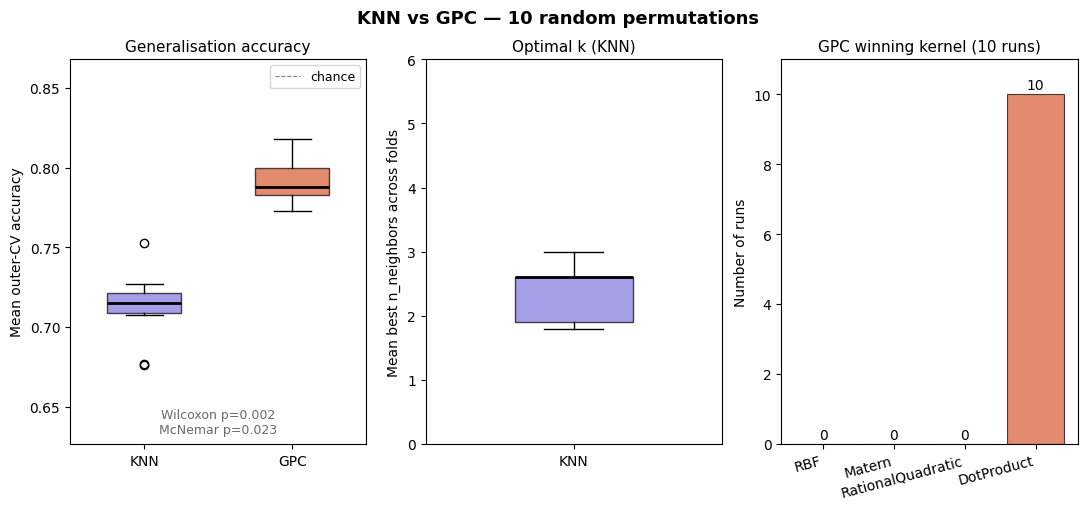

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("KNN vs GPC — 10 random permutations", fontsize=13, fontweight="bold")

# Plot 1: Model accuracy 
ax = axes[0]
bp = ax.boxplot(
    [knn_accs, gpc_accs],
    tick_labels=["KNN", "GPC"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.5,
)
colors = ["#7F77DD", "#D85A30"]           # purple / coral
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Generalisation accuracy", fontsize=11)
ax.set_ylabel("Mean outer-CV accuracy")
ax.set_ylim(
    max(0, min(knn_accs.min(), gpc_accs.min()) - 0.05),
    min(1, max(knn_accs.max(), gpc_accs.max()) + 0.05),
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="chance")
ax.legend(fontsize=9)
ax.text(0.5, 0.06, f"Wilcoxon p={p:.3f}",
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=9, color="dimgray")
ax.text(0.5, 0.02, f"McNemar p={np.median(p_values):.3f}",
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=9, color="dimgray")

# Plot 2: KNN - optimal k  
ax = axes[1]
bp2 = ax.boxplot(
    [knn_ks],
    tick_labels=["KNN"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    widths=0.4,
)
bp2["boxes"][0].set_facecolor("#7F77DD")
bp2["boxes"][0].set_alpha(0.7)
ax.set_title("Optimal k (KNN)", fontsize=11)
ax.set_ylabel("Mean best n_neighbors across folds")
ax.set_ylim(0, max(knn_ks) + 3)

# Plot 3: GPC - winning kernel function across 10 runs
ax = axes[2]

kernel_counts = Counter(gpc_kf)

# make sure all 4 kernels appear even if count is 0
all_kernels = ["RBF", "Matern", "RationalQuadratic", "DotProduct"]
counts = [kernel_counts.get(k, 0) for k in all_kernels]

bars = ax.bar(all_kernels, counts, color="#D85A30", alpha=0.7, edgecolor="black", linewidth=0.8)

# add count labels on top of each bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(count), ha="center", va="bottom", fontsize=10)

ax.set_title("GPC winning kernel (10 runs)", fontsize=11)
ax.set_ylabel("Number of runs")
ax.set_ylim(0, 10 + 1)
ax.set_xticks(range(len(all_kernels)))
ax.set_xticklabels(all_kernels, rotation=15, ha="right")

## Exploratory visualization

### K-means clustering

#### Find the right K

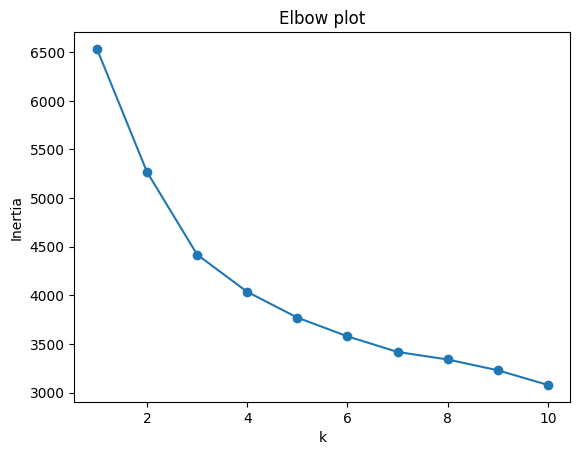

In [57]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(Xt)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow plot')
plt.show()

Optimal k: 2


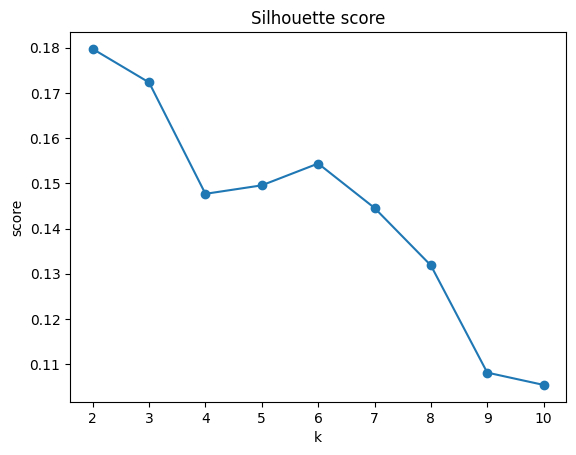

In [58]:
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Xt)
    sil_scores.append(silhouette_score(Xt, labels))

optimal_k = k_range[np.argmax(sil_scores)]
print(f"Optimal k: {optimal_k}")

plt.plot(k_range, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('score')
plt.title('Silhouette score')
plt.show()

#### Run K-means

In [59]:
# according to the elbow plot and sillhouette score, best k = 2
k = 2
kmeans = KMeans(n_clusters=k, n_init=10)
cluster_labels = kmeans.fit_predict(Xt)
cluster_centers = kmeans.cluster_centers_  # shape: (k, n_features)

### Kernel PCA projection

In [60]:
kpca = KernelPCA(n_components=2, kernel='rbf', fit_inverse_transform=True, random_state=42)
Xt_kpca = kpca.fit_transform(Xt)                        # project data
centers_kpca = np.array([
    Xt_kpca[cluster_labels == i].mean(axis=0) 
    for i in range(k)
])

print(f"centers shape: {centers_kpca.shape}")

centers shape: (2, 2)


#### Visualization of true clusters and K-means clusters

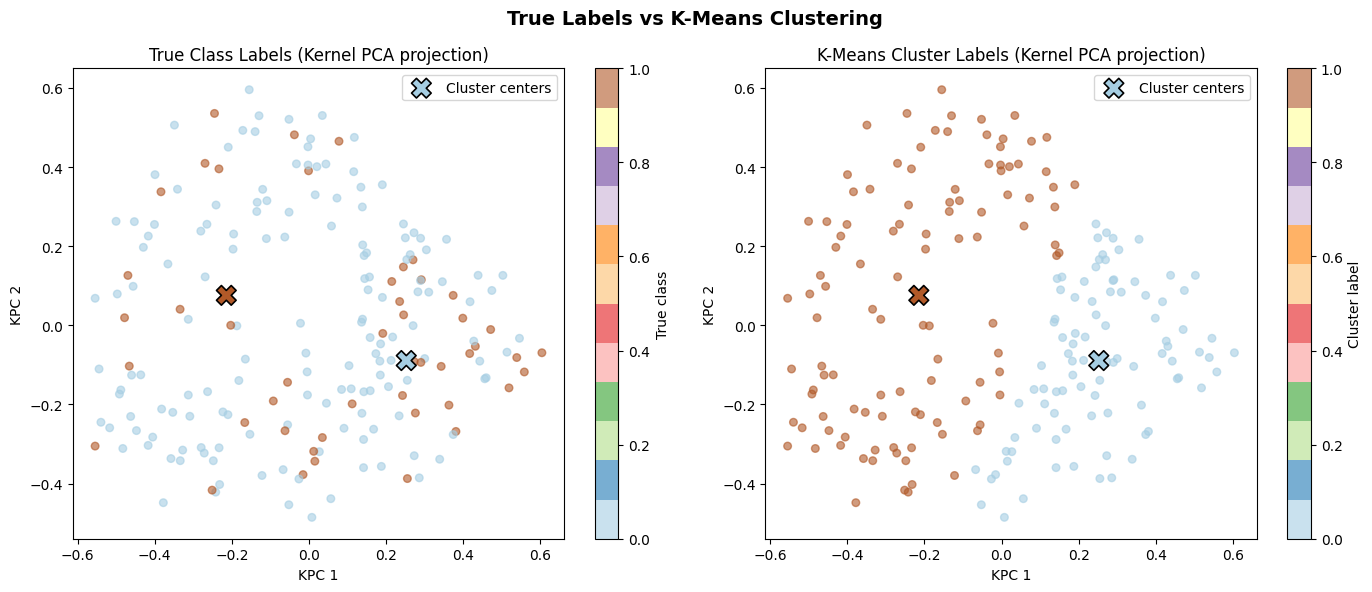

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plot true class labels
sc1 = axes[0].scatter(
    Xt_kpca[:, 0], Xt_kpca[:, 1],
    c=yt,
    cmap='Paired',
    alpha=0.6,
    s=30
)
axes[0].scatter(
    centers_kpca[:, 0], centers_kpca[:, 1],
    c=range(k),
    cmap='Paired',
    s=200,
    marker='X',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Cluster centers'
)
axes[0].set_title('True Class Labels (Kernel PCA projection)')
axes[0].set_xlabel('KPC 1')
axes[0].set_ylabel('KPC 2')
plt.colorbar(sc1, ax=axes[0], label='True class')
axes[0].legend()

# plot K-means clusters
sc2 = axes[1].scatter(
    Xt_kpca[:, 0], Xt_kpca[:, 1],
    c=cluster_labels,
    cmap='Paired',
    alpha=0.6,
    s=30
)
axes[1].scatter(
    centers_kpca[:, 0], centers_kpca[:, 1],
    c=range(k),
    cmap='Paired',
    s=200,
    marker='X',
    edgecolors='black',
    linewidths=1.2,
    zorder=5,
    label='Cluster centers'
)
axes[1].set_title('K-Means Cluster Labels (Kernel PCA projection)')
axes[1].set_xlabel('KPC 1')
axes[1].set_ylabel('KPC 2')
plt.colorbar(sc2, ax=axes[1], label='Cluster label')
axes[1].legend()

plt.suptitle('True Labels vs K-Means Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### K-means accuracy calculation

In [65]:

def cluster_accuracy(true_labels, cluster_labels):
    k = 2  # determined from elbow + silhouette
    
    conf_matrix = np.zeros((k, k), dtype=int)
    for t, c in zip(true_labels, cluster_labels):
        conf_matrix[t, c] += 1
    
    row_ind, col_ind = linear_sum_assignment(-conf_matrix)
    correct = conf_matrix[row_ind, col_ind].sum()
    accuracy = correct / len(true_labels)
    
    return accuracy, conf_matrix, col_ind

acc, conf, mapping = cluster_accuracy(yt, cluster_labels)
print(f"Cluster accuracy: {acc:.4f} ({acc*100:.2f}%)")

Cluster accuracy: 0.5960 (59.60%)
